# 06 — Hyperparameter optimisation

Randomised search over Random Forest and XGBoost, and why every gain it found was inside the noise.

**Pipeline module:** `src/tuning.py`

*Every number and figure below was produced by the pipeline in `src/`. This
notebook reads those results; it does not re-implement them.*

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
from IPython.display import Image, display

TABLES = ROOT / "results" / "tables"
FIGURES = ROOT / "results" / "figures"

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

def table(name, **kw):
    """Read one of the pipeline's result tables."""
    return pd.read_csv(TABLES / name, **kw)

def figure(name):
    """Display one of the pipeline's figures."""
    return Image(filename=str(FIGURES / name))

print(f"project root: {ROOT}")

project root: C:\Users\babu\OneDrive\Desktop\ML Project


## Method

Randomised search rather than grid search: a full grid over these ranges is thousands
of combinations, and randomised search reaches a comparable result from a small sample
because only a few hyperparameters usually matter.

15 candidates × 3 folds per model, on a 150,000-row subsample of the training split.
Each tuned result is compared against the Phase 9 defaults **scored on the same
folds**, so the comparison isolates the effect of tuning.

```bash
python src/tuning.py    # about 64 minutes on 4 cores
```

In [2]:
tune_binary = table("tuning_binary.csv")
tune_multi = table("tuning_multi.csv")
display(tune_binary.round(5))
display(tune_multi.round(5))

,model,baseline_cv_f1,baseline_cv_std,tuned_cv_f1,tuned_cv_std,gain,search_minutes
0,Random Forest,0.99493,0.00118,0.99546,0.00119,0.00053,23.12
1,XGBoost,0.99656,0.00053,0.99668,0.00074,0.00012,5.41


,model,baseline_cv_f1,baseline_cv_std,tuned_cv_f1,tuned_cv_std,gain,search_minutes
0,Random Forest,0.92928,0.00991,0.93763,0.00694,0.00835,21.09
1,XGBoost,0.95491,0.02597,0.96667,0.01208,0.01176,14.22


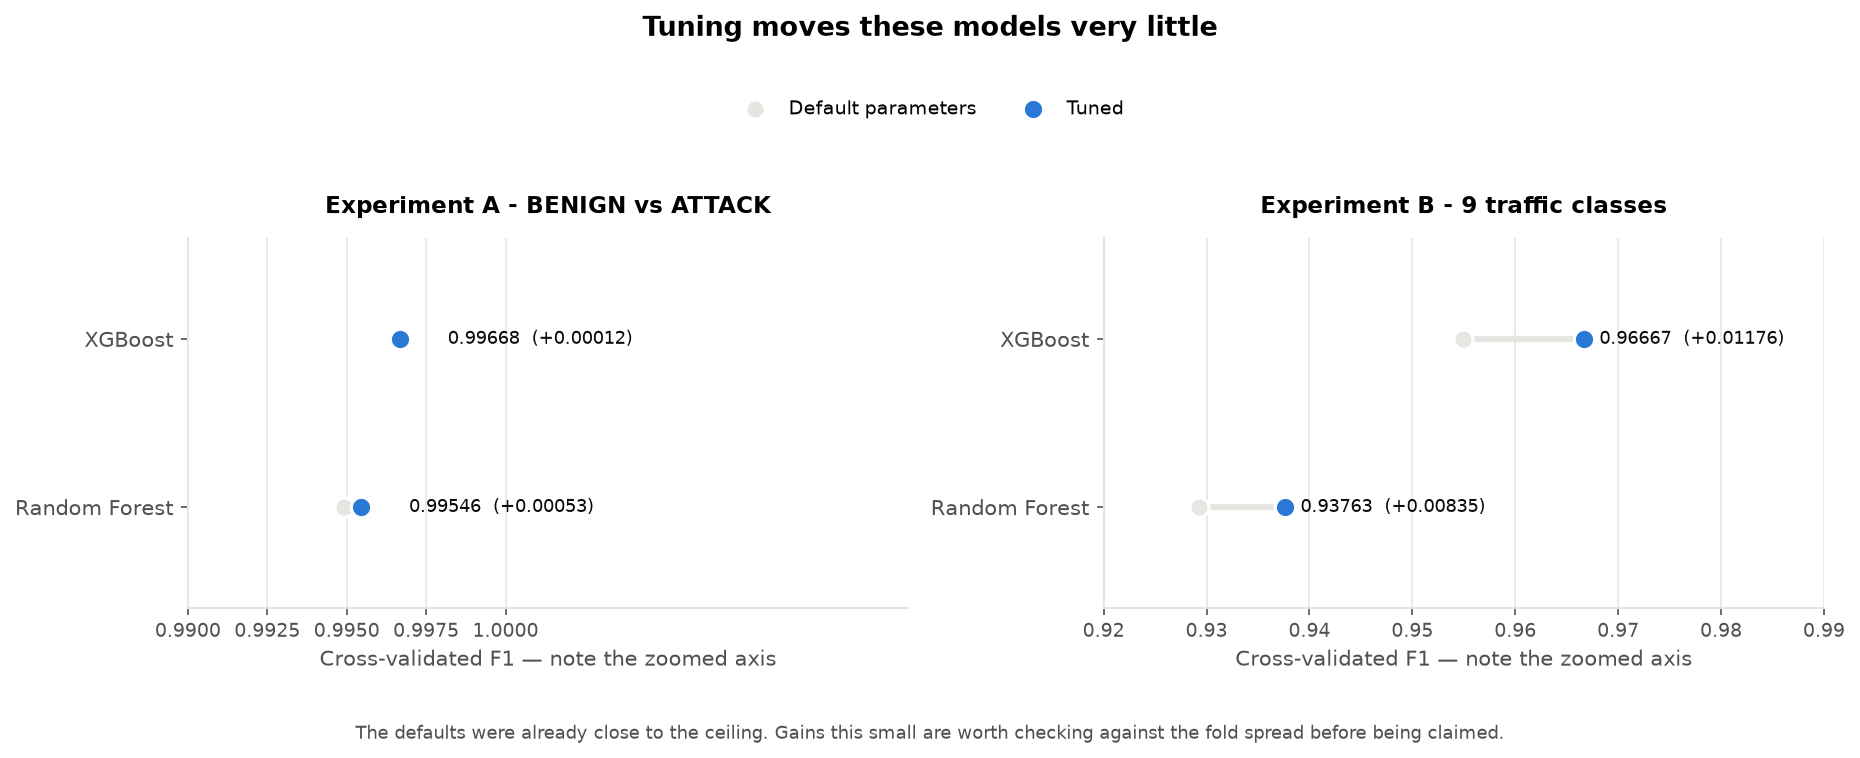

In [3]:
figure("13_hyperparameter_tuning.png")

## Every gain is inside the fold spread

| Experiment | Model | Gain | Combined spread | Verdict |
|---|---|---|---|---|
| A | Random Forest | +0.00053 | 0.00237 | not meaningful |
| A | XGBoost | +0.00012 | 0.00127 | not meaningful |
| B | Random Forest | +0.00835 | 0.01685 | not meaningful |
| B | XGBoost | +0.01176 | 0.03805 | not meaningful |

Each "improvement" is smaller than the range the same model produces just by being
trained on different slices of the same data.

One thing the mean hides: tuning **halved XGBoost's multi-class variance**, from
std 0.02597 to 0.01208. The average barely moved; the consistency genuinely improved.

In [4]:
import itertools
import json
params = json.loads((TABLES / "best_params.json").read_text())
print(json.dumps(params, indent=2))

{
  "binary": {
    "Random Forest": {
      "max_depth": null,
      "max_features": 0.4,
      "min_samples_leaf": 2,
      "min_samples_split": 4,
      "n_estimators": 314
    },
    "XGBoost": {
      "colsample_bytree": 0.7824279936868144,
      "learning_rate": 0.3248115864875547,
      "max_depth": 6,
      "min_child_weight": 4,
      "n_estimators": 154,
      "subsample": 0.9932923543227152
    }
  },
  "multi": {
    "Random Forest": {
      "max_depth": null,
      "max_features": 0.4,
      "min_samples_leaf": 2,
      "min_samples_split": 4,
      "n_estimators": 314
    },
    "XGBoost": {
      "colsample_bytree": 0.9861021229056552,
      "learning_rate": 0.26246198669033965,
      "max_depth": 8,
      "min_child_weight": 1,
      "n_estimators": 256,
      "subsample": 0.9208787923016158
    }
  }
}


## Where the gains actually came from

| Change | Multi-class F1 effect |
|---|---|
| Removing 329,691 duplicate rows | prevented an inflated score outright |
| Feature selection (70 → 25) | **+0.0165** |
| Hyperparameter tuning | +0.00012 (binary), and it *lost* on the test set |

**Data quality beat model configuration by two orders of magnitude.** That is the
opposite of where most effort usually goes, and notebook 07 confirms it on held-out
data: the tuned multi-class model scores *lower* than the defaults, so the defaults
ship.